In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd

### Funciones

In [3]:
def gaussiana(f, A, f0, sigma, y0):
    return A * np.exp(-((f - f0)**2) / (2 * sigma**2)) + y0

In [50]:
def metricas_ajuste(x, y, y_err, popt, funcion_modelo):
    """
    Calcula R^2, Chi^2 y Chi^2 reducido para un ajuste.
    
    Parámetros:
    - x, y: Datos de entrada (array-like).
    - y_err: Incertidumbres en Y (array-like).
    - popt: Lista de parámetros optimizados devueltos por curve_fit.
    - funcion_modelo: La función usada en curve_fit (ej. recta).
    """
    x = np.array(x)
    y = np.array(y)
    y_err = np.array(y_err)
    
    # Valore predichos por el modelo
    y_pred = funcion_modelo(x, *popt)
    
    # 1. Residuales
    residuos = y - y_pred
    
    # 2. Coeficiente de Determinación R^2
    ss_res = np.sum(residuos**2)                  # Suma de cuadrados residual
    ss_tot = np.sum((y - np.mean(y))**2)         # Suma de cuadrados total
    r2 = 1 - (ss_res / ss_tot)
    
    # 3. Chi-cuadrado (Chi2)
    chi2 = np.sum((residuos / y_err)**2)
    
    # 4. Grados de libertad (nu = n - p)
    # n: número de datos, p: número de parámetros ajustados
    n = len(y)
    p = len(popt)
    dof = n - p
    
    # 5. Chi-cuadrado reducido (Chi2_nu)
    chi2_red = chi2 / dof if dof > 0 else np.nan
    
    return {
        "R2": r2,
        "Chi2": chi2,
        "Grados_Libertad": dof,
        "Chi2_reducido": chi2_red
    }

### Importando los datos

In [4]:
path_file = r"..\mediciones\clase2\clean\mediciones_parte1_clean.csv"

In [5]:
datos = pd.read_csv(path_file, sep=",")
datos.head(5)

,frecuencia,vpp,vpp_error
0,35.0,10.0,0.3
1,36.0,32.0,1.0
2,37.0,74.0,2.0
3,38.0,188.0,6.0
4,38.1,202.0,6.0


### Gráficamos las observaciones

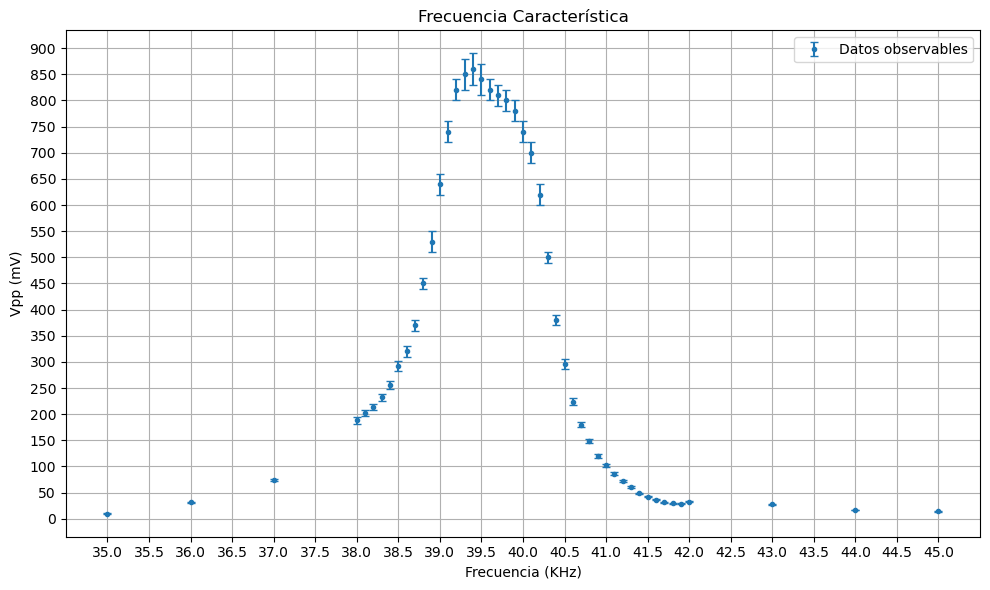

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))

# observaciones
ax.errorbar(
    x=datos["frecuencia"],
    y=datos["vpp"],
    yerr=datos["vpp_error"],
    fmt='.',
    capsize=3,
    label="Datos observables"
)
ax.set_xticks(np.arange(35, 45.5, 0.5))
ax.set_yticks(np.arange(0, 950, 50))
ax.set_title("Frecuencia Característica")
ax.set_xlabel("Frecuencia (KHz)")
ax.set_ylabel("Vpp (mV)")
ax.legend()
ax.grid(True)
plt.tight_layout()

# guardamos 
path_save = r"..\graficos\clase2\observaciones.png"
plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

### Ajuste gaussiano - rango completo

In [44]:
# Estimaciones iniciales
p0_guess = [
    datos["vpp"].max(),      # Amplitud aproximada
    39.5,                    # Valor central aproximada 
    0.68,                    # Ancho estimado sigma
    datos["vpp"].min()       # Nivel base
]

In [45]:
# realizamos un ajuste por mínimos cuadrados ponderados
popt, pcov = curve_fit(
    f =gaussiana,
    xdata=datos["frecuencia"],
    ydata=datos["vpp"],
    p0=p0_guess,
    sigma=datos["vpp_error"], 
    absolute_sigma=True
)

In [46]:
popt, pcov

(array([745.49529584,  39.48088835,   0.75981523,  16.51354335]),
 array([[ 3.16028427e+01,  4.86347417e-03, -1.07277097e-02,
          1.09886010e-01],
        [ 4.86347417e-03,  1.23398117e-05, -4.92923060e-06,
         -6.15390405e-06],
        [-1.07277097e-02, -4.92923060e-06,  7.23374652e-06,
         -1.54288200e-04],
        [ 1.09886010e-01, -6.15390405e-06, -1.54288200e-04,
          3.66628991e-02]]))

In [47]:
# Extraer los valores óptimos y sus errores (raíz de la diagonal de la covarianza)
A_opt, f0_opt, sigma_opt, y0_opt = popt
errores = np.sqrt(np.diag(pcov))
df0 = errores[1]  # Error de la frecuencia característica f0
print("f0=", f0_opt, "sigma_f0=", df0)

f0= 39.48088835448605 sigma_f0= 0.0035128068135531483


In [48]:
print(f"Frecuencia característica f0 = ({f0_opt:.3f} ± {df0:.3f}) kHz")

Frecuencia característica f0 = (39.481 ± 0.004) kHz


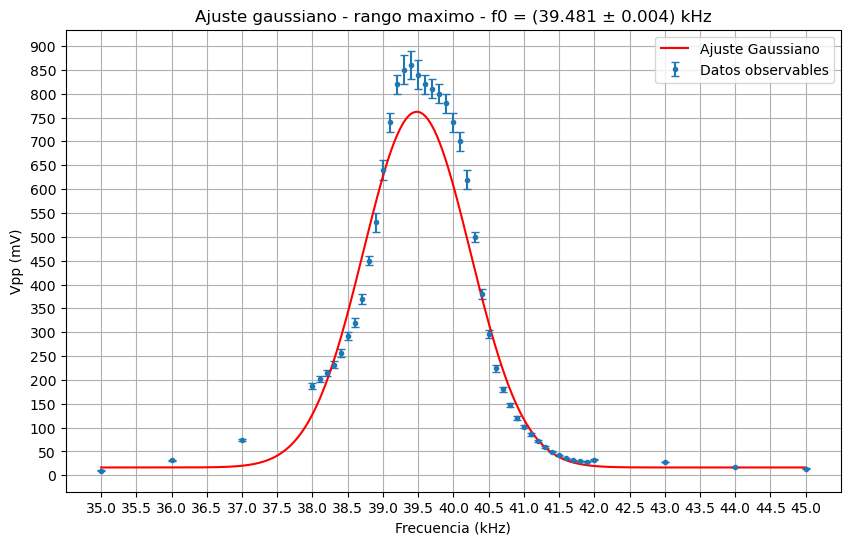

In [49]:
# 5. Graficar los datos y la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = gaussiana(f_fit, *popt)

plt.figure(figsize=(10, 6))
plt.errorbar(datos['frecuencia'], datos['vpp'], yerr=datos['vpp_error'], fmt='.', label='Datos observables', capsize=3)
plt.plot(f_fit, vpp_fit, 'r-', label='Ajuste Gaussiano')

plt.xticks(np.arange(35, 45.5, 0.5))
plt.yticks(np.arange(0, 950, 50))

plt.title(f'Ajuste gaussiano - rango maximo - f0 = ({f0_opt:.3f} ± {df0:.3f}) kHz')
plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Vpp (mV)')

plt.grid(True)
plt.legend()

# guardamos 
#path_save = r"..\graficos\clase2\ajuste_gaussiano_rango_maximo.png"
#plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

### Ajuste gaussiano - zona de resonancia

In [29]:
df_pico = datos[(datos['frecuencia'] >= 37.5) & (datos['frecuencia'] <= 41.5)]

In [34]:
(df_pico['vpp'].max() - df_pico['vpp'].min())/2 + df_pico['vpp'].min()

np.float64(451.0)

In [35]:
# el pico se vuelve mas angosto

p0_guess = [
    df_pico['vpp'].max(),  # Amplitud estimada (~860)
    39.5,                  # Frecuencia central estimada
    0.68,                   # Ancho estimado (sigma)
    df_pico['vpp'].min()   # Nivel base del piso
]


In [36]:
popt, pcov = curve_fit(
    gaussiana, 
    df_pico['frecuencia'], 
    df_pico['vpp'], 
    p0=p0_guess, 
    sigma=df_pico['vpp_error'], 
    absolute_sigma=True
)

In [38]:
popt, np.diag(pcov)

(array([8.09947954e+02, 3.94890608e+01, 6.85953579e-01, 3.29795336e+01]),
 array([4.33834401e+01, 1.14505102e-05, 1.46622913e-05, 1.07171835e+00]))

In [40]:
A_opt, f0_opt, sigma_opt, y0_opt = popt
errores = np.sqrt(np.diag(pcov))
df0 = errores[1]
f0_opt, df0

(np.float64(39.48906078783525), np.float64(0.003383860248881233))

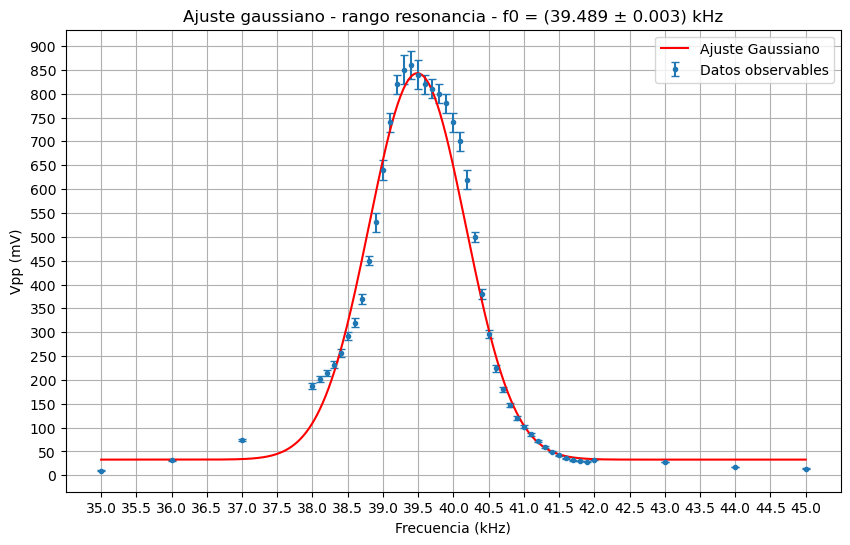

In [43]:
# 5. Graficar los datos y la curva ajustada
f_fit = np.linspace(datos['frecuencia'].min(), datos['frecuencia'].max(), 500)
vpp_fit = gaussiana(f_fit, *popt)

plt.figure(figsize=(10, 6))
plt.errorbar(datos['frecuencia'], datos['vpp'], yerr=datos['vpp_error'], fmt='.', label='Datos observables', capsize=3)
plt.plot(f_fit, vpp_fit, 'r-', label='Ajuste Gaussiano')

plt.xticks(np.arange(35, 45.5, 0.5))
plt.yticks(np.arange(0, 950, 50))

plt.title(f'Ajuste gaussiano - rango resonancia - f0 = ({f0_opt:.3f} ± {df0:.3f}) kHz')
plt.xlabel('Frecuencia (kHz)')
plt.ylabel('Vpp (mV)')

plt.grid(True)
plt.legend()

# guardamos 
#path_save = r"..\graficos\clase2\ajuste_gaussiano_rango_resonancia.png"
#plt.savefig(path_save, dpi=300, bbox_inches='tight')

plt.show()

### Ajuste gaussiano

El modelo: $y(x) = y_0 + A. \exp(\frac{-(x-x_c)^2}{2\sigma^2}) $

In [85]:
resultados = pd.DataFrame(columns=["min", "max", "a", "xc", "sigma", "y0", "a_error", "xc_error", "sigma_error", "y0_error","R2", "Chi2", "Chi2_reducido", "grados_libertad"])

In [86]:
resultados

,min,max,a,xc,sigma,y0,a_error,xc_error,sigma_error,y0_error,R2,Chi2,Chi2_reducido,grados_libertad


In [97]:
# rango para el dominio
minimo = 37.5
maximo = 41.5
df_ajuste = datos[(datos["frecuencia"] >= minimo) & (datos["frecuencia"] <= maximo)]

In [98]:
# el estimador para saber el vpp del medio, para saber su ancho FWHM
(df_ajuste['vpp'].max() - df_ajuste['vpp'].min()) /2 + df_ajuste['vpp'].min()

np.float64(451.0)

In [99]:
# en el grafico a 435 da 0.8 el ancho desde el valor central 39.5, entonces FWHM = 1.6
s = (0.7 * 2) / 2.35
s

0.5957446808510638

In [100]:
# estos estimadores para las constantes las veo por grafico
# p0 = amplitud(vpp), " x(frecuencia) central", sigma, y0
p0 = [
    df_ajuste['vpp'].max(),
    39.5,
    s,
    df_ajuste['vpp'].min()
]

In [101]:
popt, pcov = curve_fit(
    f=gaussiana,
    xdata=df_ajuste['frecuencia'],
    ydata=df_ajuste['vpp'],
    p0=p0,
    sigma=df_ajuste['vpp_error'],
    absolute_sigma=True
)

In [102]:
a, xc, sigma, y0 = popt
a_error, xc_error, sigma_error, y0_error = np.sqrt(np.diag(pcov))

In [103]:
metrics = metricas_ajuste(df_ajuste['frecuencia'], df_ajuste['vpp'], df_ajuste['vpp_error'], popt, gaussiana)
metrics

{'R2': np.float64(0.9705560804644265),
 'Chi2': np.float64(749.234633162128),
 'Grados_Libertad': 32,
 'Chi2_reducido': np.float64(23.4135822863165)}

In [104]:
pcov

array([[ 4.33836321e+01,  3.36345814e-03, -1.60416503e-02,
         1.63896402e+00],
       [ 3.36345814e-03,  1.14504736e-05, -1.90422914e-06,
        -5.41351960e-04],
       [-1.60416503e-02, -1.90422914e-06,  1.46621416e-05,
        -2.94458955e-03],
       [ 1.63896402e+00, -5.41351960e-04, -2.94458955e-03,
         1.07170682e+00]])

In [105]:
resultados

,min,max,a,xc,sigma,y0,a_error,xc_error,sigma_error,y0_error,R2,Chi2,Chi2_reducido,grados_libertad
0,35.0,45.0,745.495247,39.480888,0.759815,16.513543,5.62164,0.003513,0.00269,0.191476,0.957897,3048.92292,70.905184,43


In [106]:
resultados.loc[len(resultados)] = {
    "min":minimo,
    "max":maximo,
    "a":a,
    "xc":xc,
    "sigma":sigma,
    "y0":y0,
    "a_error":a_error,
    "xc_error":xc_error,
    "sigma_error":sigma_error,
    "y0_error":y0_error,
    "R2":metrics['R2'],
    "Chi2":metrics['Chi2'],
    "Chi2_reducido":metrics['Chi2_reducido'],
    "grados_libertad":metrics['Grados_Libertad']
}
resultados

,min,max,a,xc,sigma,y0,a_error,xc_error,sigma_error,y0_error,R2,Chi2,Chi2_reducido,grados_libertad
0,35.0,45.0,745.495247,39.480888,0.759815,16.513543,5.621640,0.003513,0.002690,0.191476,0.957897,3048.922920,70.905184,43
1,37.5,41.5,809.948355,39.489061,0.685953,32.979585,6.586625,0.003384,0.003829,1.035233,0.970556,749.234633,23.413582,32


In [109]:
path_ajuste = r".\clase2\ajuste_gaussiano_resultados.csv"
resultados.to_csv(path_ajuste, index=False)